In [1]:
!pip install nibabel
!pip install nilearn

In [2]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import nibabel as nib
from nilearn import plotting

In [3]:
table1_paths = [
    "tractor/structural/T1w_vol1.nii.gz",
    "tractor/structural/parcellation.nii.gz",
    "tractor/structural/parcellation.lut",
    "tractor/diffusion/data.nii.gz",
    "tractor/diffusion/dti_FA.nii.gz",
    "tractor/diffusion/parcellation.nii.gz",
    "tractor/functional/data.nii.gz",
    "tractor/functional/parcellation.nii.gz"
]

In [4]:
target_file = f"Task1Data/{table1_paths[1]}"  

In [5]:
img = nib.load(target_file)

# get voxel data
data = img.get_fdata()

print(data.shape)

(176, 232, 256)


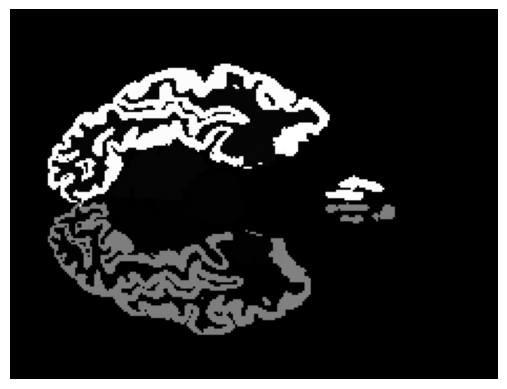

In [6]:
slice_index = data.shape[2] // 2

plt.imshow(data[:, :, slice_index], cmap="gray")
plt.axis("off")
plt.show()

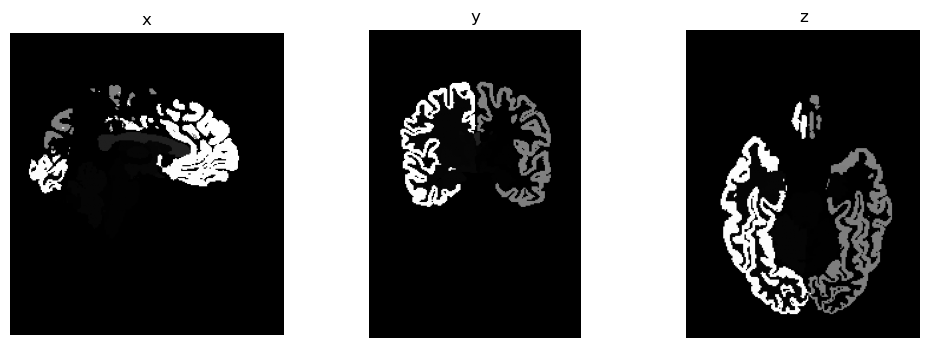

In [7]:
x = data.shape[0] // 2
y = data.shape[1] // 2
z = data.shape[2] // 2

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(data[x,:,:].T, cmap="gray", origin="lower")
ax[0].set_title("x")

ax[1].imshow(data[:,y,:].T, cmap="gray", origin="lower")
ax[1].set_title("y")

ax[2].imshow(data[:,:,z].T, cmap="gray", origin="lower")
ax[2].set_title("z")

for a in ax:
    a.axis("off")

plt.show()

c:\Users\james\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
C:\Users\james\AppData\Local\Temp\ipykernel_45696\1505682581.py:1: UserWarning: Casting data from int32 to float32
  plotting.view_img(img)



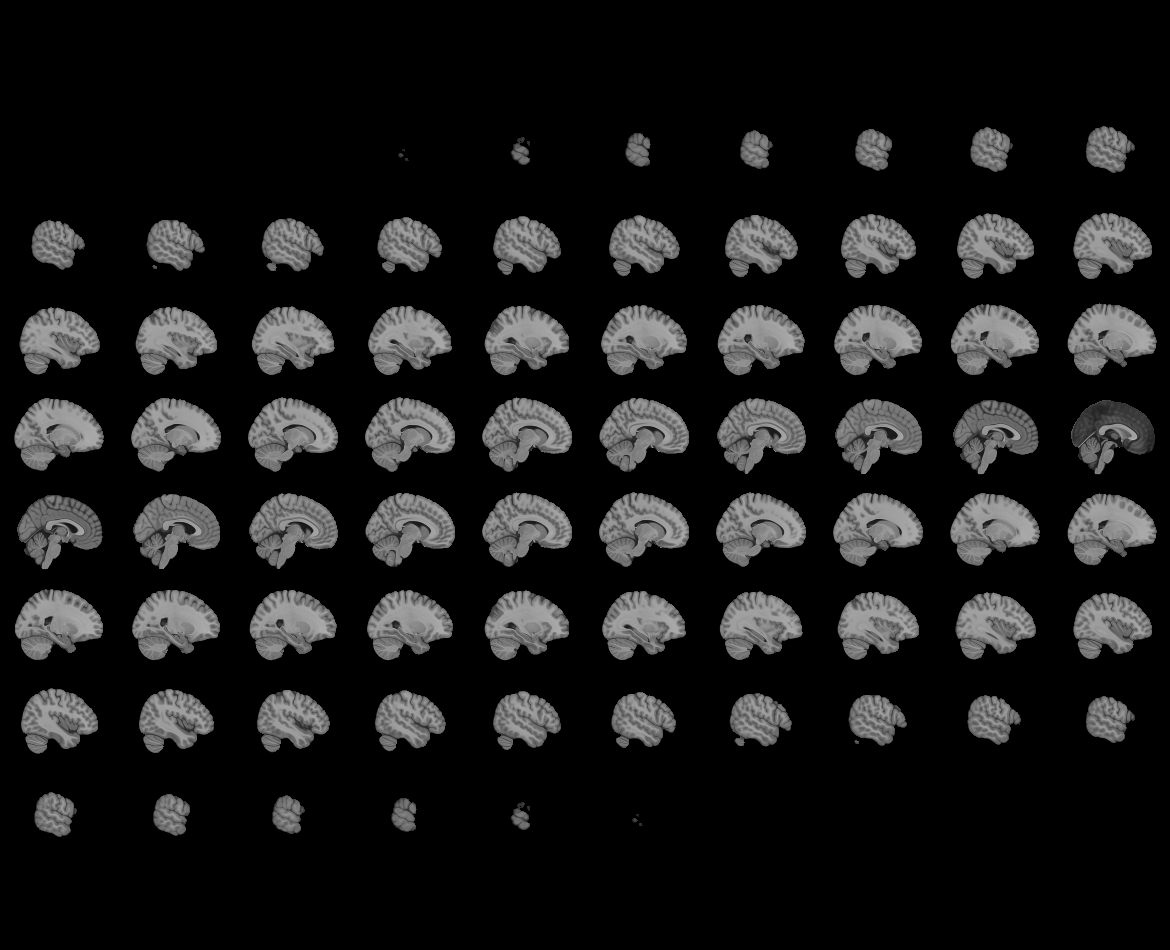
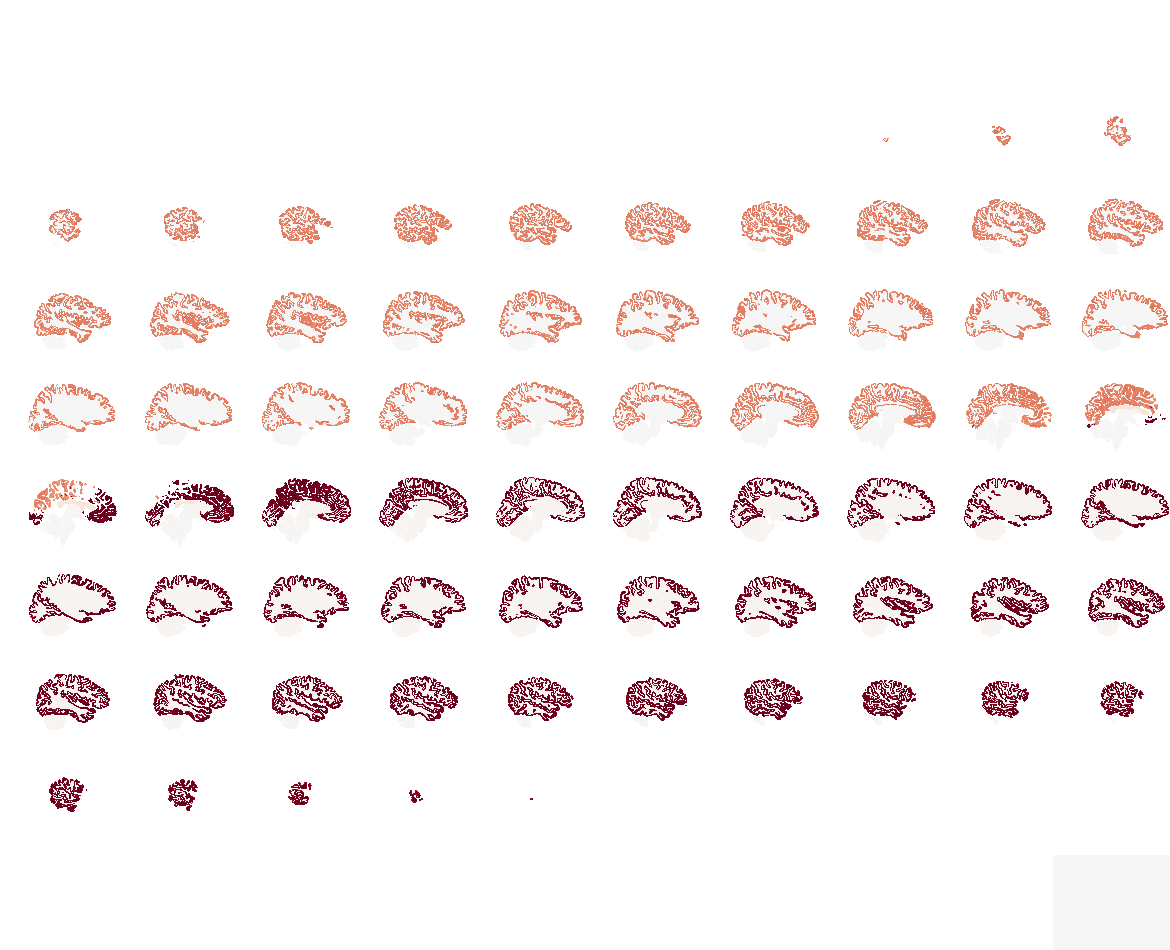

In [8]:
plotting.view_img(img)

c:\Users\james\anaconda3\Lib\site-packages\matplotlib\colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


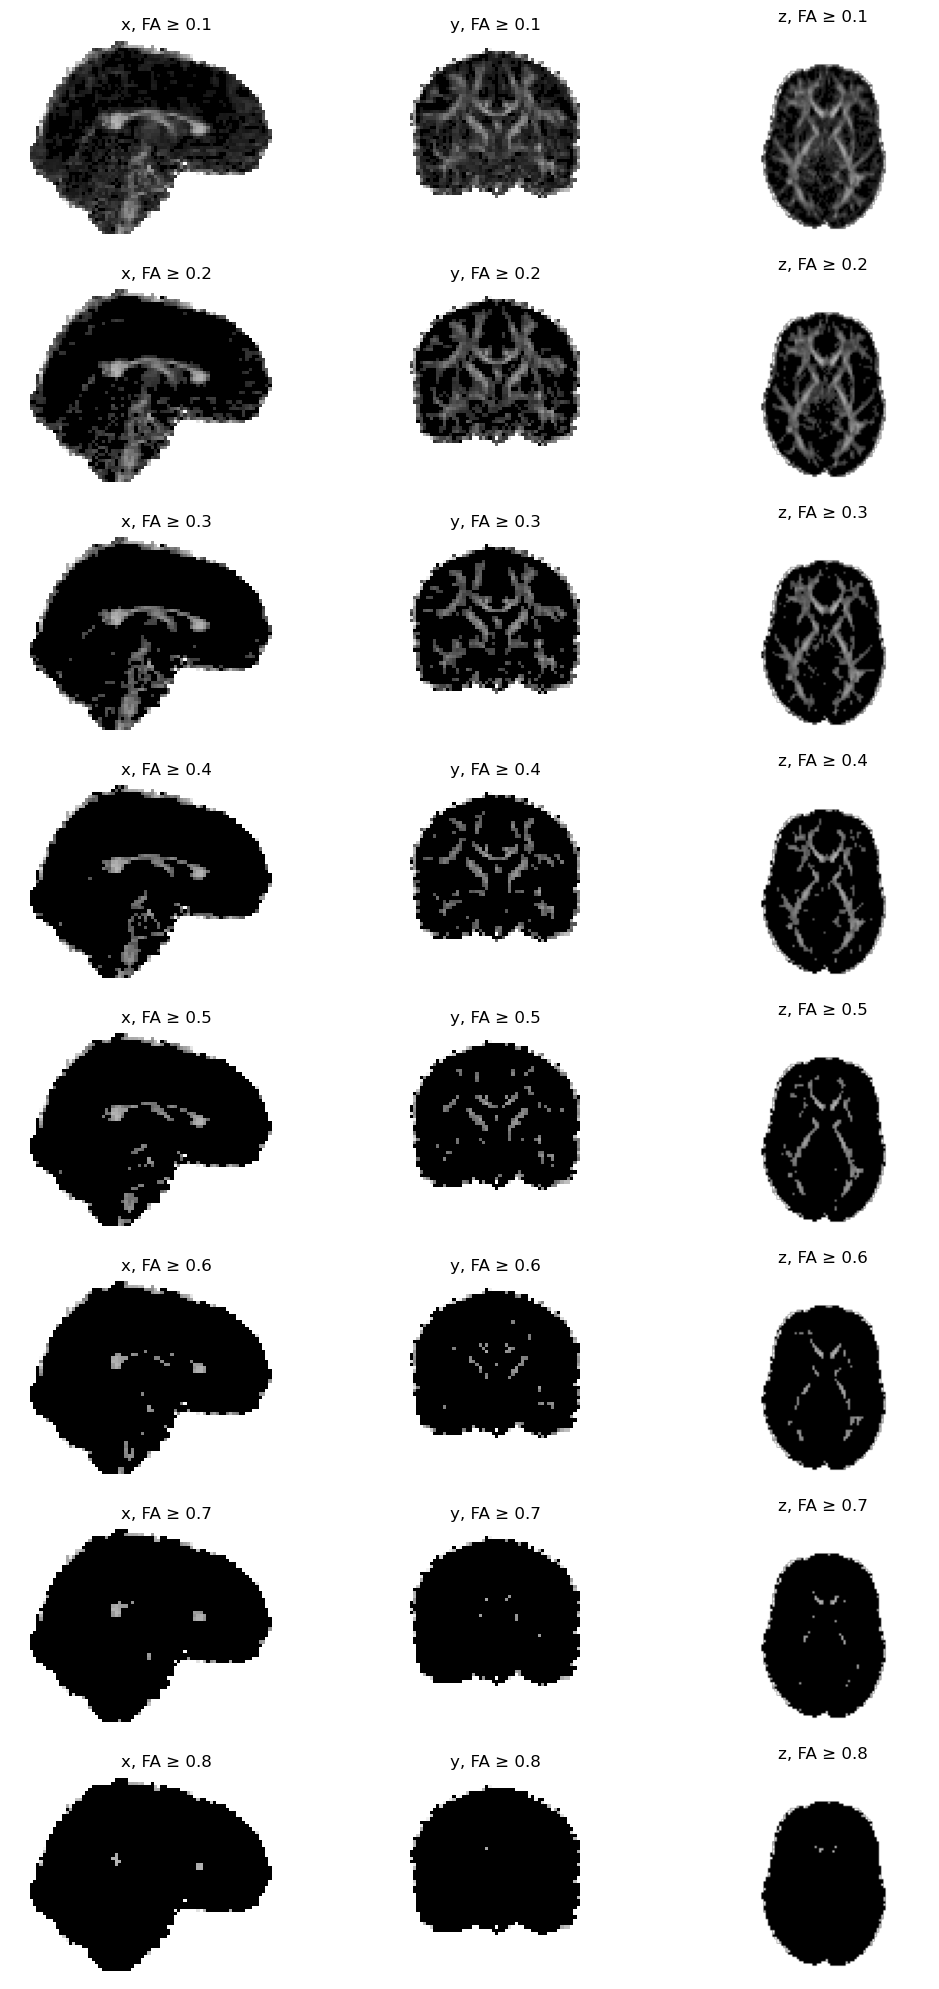

In [9]:
# FA MAP
fa = nib.load(f"Task1Data/{table1_paths[4]}").get_fdata()


thresholds = np.arange(0.1, 0.9, 0.1)

x = fa.shape[0] // 2
y = fa.shape[1] // 2
z = fa.shape[2] // 2

fig, axes = plt.subplots(len(thresholds), 3, figsize=(10, 2.5 * len(thresholds)))

for i, th in enumerate(thresholds):
    fa_thr = fa.copy()
    fa_thr[fa_thr < th] = 0

    axes[i, 0].imshow(fa_thr[x, :, :].T, cmap="gray", origin="lower")
    axes[i, 0].set_title(f"x, FA ≥ {th:.1f}")

    axes[i, 1].imshow(fa_thr[:, y, :].T, cmap="gray", origin="lower")
    axes[i, 1].set_title(f"y, FA ≥ {th:.1f}")

    axes[i, 2].imshow(fa_thr[:, :, z].T, cmap="gray", origin="lower")
    axes[i, 2].set_title(f"z, FA ≥ {th:.1f}")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()